# **🗂️​ Pre-Entrega PFI 📊​**
**🌸​-- Milagros Romeo --🌸​**


---

# **📍​Índice**


> **✅​ Etapa 1: Recopilación y Preparación de Datos (EDA)**

En esta primera etapa, se hace la creación del notebook y carga de los set de datos como Dataframes.

Una vez cargados, se hace un análisis exploratorio (EDA) y la identificación de valores nulos y duplicados en los conjuntos de datos.

> **✅​ Etapa 2: Preprocesamiento y Limpieza de Datos**

* **Limpieza de Datos**: Se limpia el conjunto de datos eliminando duplicados y caracteres no deseados.


* **Transformación de Datos**: Se aplican los filtros y transformaciones para crear una tabla de ventas que muestre *solo* los productos con alto rendimiento.

* **Agregación**: Resumo las ventas por categoría de producto y analizar los ingresos generados.

* **Integración de Datos**: Combinación de los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.



# **📎​Etapa 1: Recopilación y preparación de Datos**

In [ ]:
import pandas as pd

def cargar_dataset(link):
  # regex para extraer el file_ID
  file_id = link.split('d/')[1].split('/')[0]

  url = f"https://drive.google.com/uc?id={file_id}" # genera la url

  # importamos con 'read_csv()' con la url generada
  df = pd.read_csv(url)
  return df


Una vez definida la función para cargar los dataset, separo el análisis exploratorio entre los set de datos para hacer una lectura más cómoda.

In [ ]:
def resumen_EDA(dataframe):
  print(f"📐​ Tamaño del DataFrame")
  print("Columnas:", dataframe.shape[1])
  print(f"Filas:", dataframe.shape[0])

  print("-" * 64)

  print("📌​ Tipos de datos")
  print(dataframe.dtypes)

  print("-" * 64)

  print("🔎 Valores nulos por columna")
  print(dataframe.isnull().sum())

  print("-" * 64)

  print("🔎 Valores duplicados")
  print(dataframe.duplicated().sum())

  print("-" * 64)

  print("📈 Estadísticas descriptivas")
  print(dataframe.describe(include="number"))
  print("-" * 64)

  print("📈 Estadísticas descriptivas")
  print(dataframe.describe(include="object"))

  print("-" * 64)

  return



#### **✅​ EDA Clientes**



In [ ]:
link = "https://drive.google.com/file/d/1pyNXpqnOauR5tWJWj9f8C15Ygn5HmdWT/view?usp=drive_link"
df_clientes = cargar_dataset(link)
df_clientes.head()

resumen_EDA(df_clientes)

📐​ Tamaño del DataFrame
Columnas: 5
Filas: 567
----------------------------------------------------------------
📌​ Tipos de datos
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object
----------------------------------------------------------------
🔎 Valores nulos por columna
id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64
----------------------------------------------------------------
🔎 Valores duplicados
0
----------------------------------------------------------------
📈 Estadísticas descriptivas
       id_cliente        edad      ingresos
count  567.000000  567.000000    567.000000
mean   284.000000   37.940035  34668.739012
std    163.823075   10.202885  12974.531446
min      1.000000   20.000000    170.290000
25%    142.500000   30.000000  26015.240000
50%    284.000000   37.000000  35066.830000
75%    425.500000   43.000000  42457.100000
max    567.000000   81.0000

Luego de ver el análisis exploratorio en el dataframe de clientes, noto que no presenta anomalías. **Dataset clean ✅**

#### **✅​EDA Ventas**

In [ ]:
link = "https://drive.google.com/file/d/1dpvV5iOAKyD7QZX8gwAZVZIefWGpnTKM/view?usp=drive_link"
df_ventas = cargar_dataset(link)
df_ventas.head()

resumen_EDA(df_ventas)

📐​ Tamaño del DataFrame
Columnas: 6
Filas: 3035
----------------------------------------------------------------
📌​ Tipos de datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object
----------------------------------------------------------------
🔎 Valores nulos por columna
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
dtype: int64
----------------------------------------------------------------
🔎 Valores duplicados
35
----------------------------------------------------------------
📈 Estadísticas descriptivas
          id_venta     cantidad
count  3035.000000  3033.000000
mean   1499.851400     6.496538
std     866.465379     3.457250
min       1.000000     1.000000
25%     748.500000     3.000000
50%    1502.000000     7.000000
75%    2249.500000     9.000000
max    3000.000000    12.000000
---------------------------------------

El análisis presentó las siguientes anomalías/cosas a corregir:

* 📉​ Tratamiento de tipos de datos.

columna precio: type object -> convertir a float y eliminar el carácter '$' para mejor análisis.

columna cantidad: type float -> convertir a int

columna fecha_venta: tipo object -> convertir date_time

*  📉​ Tratamientos de nulos.
            
columna precio: 2

columna cantidad: 2

* 📉​ Tratamiento sobre 35 filas duplicadas.


#### **✅​EDA Marketing**

In [ ]:
link = "https://drive.google.com/file/d/1NV-ICitmc8HQjhNEuUcgKqvajoBbNBT5/view?usp=drive_link"
df_marketing = cargar_dataset(link)
df_marketing.head()

resumen_EDA(df_marketing)

📐​ Tamaño del DataFrame
Columnas: 6
Filas: 90
----------------------------------------------------------------
📌​ Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------------------------------
🔎 Valores nulos por columna
id_campanha     0
producto        0
canal           0
costo           0
fecha_inicio    0
fecha_fin       0
dtype: int64
----------------------------------------------------------------
🔎 Valores duplicados
0
----------------------------------------------------------------
📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
------------------------------------------------

El análisis presentó las siguientes anomalías/a corregir:

* 📉​ Tratamiento de tipos de datos.

columna fecha_inicio: tipo object -> convertir date_time

columna fecha_fin: tipo object -> convertir date_time

*  📉​ Tratamientos de nulos.
            
No posee valores nulos.

* 📉​ Tratamiento sobre filas duplicadas.

No posee filas duplicadas.


# **📎​Etapa 2: Preprocesamiento y Limpieza de Datos**

---
### **Limpieza de datos 🧹​**

Limpio los DataFrames eliminando tratando los datos nulos, duplicados y caracteres no deseados.

#### Limpieza sobre df_ventas 🧹​

In [ ]:
######### TRATAMIENTO DE TIPOS DE DATOS ##############
'''
precio: type object -> convertir a float y eliminar el carácter '$' para mejor análisis.
cantidad: type float -> convertir a int
fecha_venta: type object -> convertir date_time
'''

df_ventas_clean = df_ventas.copy()

# COLUMNA PRECIO

# elimino el símbolo '$'
df_ventas_clean["precio"] = df_ventas_clean["precio"].str.replace("$", "", regex=False)

# convertir type a tipo numérico con errors='coerce'
df_ventas_clean["precio"] = pd.to_numeric(df_ventas_clean["precio"], errors="coerce")
df_ventas_clean["precio"].head(3)

,precio
0,69.94
1,105.10
2,97.96


In [ ]:
# COLUMNA PRECIO
df_ventas_clean['precio'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3035 entries, 0 to 3034
Series name: precio
Non-Null Count  Dtype  
--------------  -----  
3033 non-null   float64
dtypes: float64(1)
memory usage: 23.8 KB


In [ ]:
# COLUMNA CANTIDAD
df_ventas_clean["cantidad"] = pd.to_numeric(df_ventas_clean["cantidad"], errors = 'coerce')
df_ventas_clean['cantidad'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3035 entries, 0 to 3034
Series name: cantidad
Non-Null Count  Dtype  
--------------  -----  
3033 non-null   float64
dtypes: float64(1)
memory usage: 23.8 KB


In [ ]:
# COLUMNA FECHA_VENTA
df_ventas_clean["fecha_venta"] = pd.to_datetime(df_ventas_clean["fecha_venta"], dayfirst=True, errors="coerce", format='mixed') # cambio de tipo a 'datetime'
df_ventas_clean['fecha_venta'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3035 entries, 0 to 3034
Series name: fecha_venta
Non-Null Count  Dtype         
--------------  -----         
3035 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 23.8 KB


In [ ]:
######### TRATAMIENTO DE DATOS NULOS ##############
'''
Tratamientos de nulos.
COLUMNA PRECIO: 2
COLUMNA CANTIDAD: 2
'''

df_ventas_clean.isnull().sum()
df_ventas_clean['cantidad'] = df_ventas_clean['cantidad'].fillna(0)
df_ventas_clean['precio'] = df_ventas_clean['precio'].fillna(0)

# Ahora que los nulos han sido tratados, convierto 'cantidad' a tipo entero, más arriba no podía modificarlo ya que no se puede modificar Nan -> Int
df_ventas_clean['cantidad'] = df_ventas_clean['cantidad'].astype(int)

df_ventas_clean.isnull().sum() # ahora hay 0 nulos en las columnas

,0
id_venta,0
producto,0
precio,0
cantidad,0
fecha_venta,0
categoria,0


In [ ]:
######### TRATAMIENTO DE DATOS DUPLICADOS ##############
'''
tratamiento sobre 35 filas duplicadas
'''
df_ventas_clean.duplicated().sum() # muestra 35

df_ventas_clean.drop_duplicates(inplace=True)
df_ventas_clean.duplicated().sum() # ahora 0

np.int64(0)

#### Limpieza sobre df_marketing 🧹​

In [ ]:
df_marketing_clean = df_marketing.copy()

df_marketing_clean['fecha_inicio'] = pd.to_datetime(df_marketing_clean['fecha_inicio'], errors='raise', format='mixed')
df_marketing_clean['fecha_fin'] = pd.to_datetime(df_marketing_clean['fecha_fin'], errors='raise', format='mixed')

df_marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


---
### **Transformación de datos 🔄​**

Se aplican filtros y transformaciones para crear una tabla de ventas que muestre solo los productos con alto rendimiento.

Interpreto como "alto rendimiento" aquellos productos cuyos ingresos totales superan el promedio de la muestra. Los pasos serán:

-) Añadir una columna total_ventas = precio * cantidad

-) Los productos que superen la media de total_ventas son aquellos que poseen mayor rendimiento

In [ ]:
df_ventas_clean['total_ventas'] = df_ventas_clean['cantidad'] * df_ventas_clean['precio']
media = df_ventas_clean["total_ventas"].mean()
print(media) # 489.03

df_altoRendimiento = df_ventas_clean[df_ventas_clean['total_ventas'] > media].reset_index(drop=True)
df_altoRendimiento.head(15)

489.03117333333336


,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_ventas
0,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50
1,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80
2,2959,Proyector,88.17,9,2024-01-02,Electrónica,793.53
3,318,Rincón de plantas,79.86,11,2024-01-03,Decoración,878.46
4,419,Candelabro,66.11,8,2024-01-03,Decoración,528.88
5,2794,Tablet,67.97,9,2024-01-03,Electrónica,611.73
6,630,Adorno de pared,71.99,9,2024-01-04,Decoración,647.91
7,794,Jarrón decorativo,96.97,7,2024-01-04,Decoración,678.79
8,882,Cuadro decorativo,101.92,9,2024-01-04,Decoración,917.28
9,969,Candelabro,90.70,12,2024-01-04,Decoración,1088.40


---
### **Agregación ➕​**

Resumir las ventas por categoría de producto y analizar los ingresos generados.


In [ ]:
# trabajo sobre una copia del DataFrame de Ventas limpio
df_agregacion = df_ventas_clean.copy()

# como en el ítem anterior, hago una columna de ventas por producto.
# ventas_por_producto -> ganancia total
df_agregacion['venta_por_producto'] = df_agregacion['precio'] * df_agregacion['cantidad']

# agrupo por categoría y sumo todos los productos que tengan la misma categoría
ventas_por_categoria = df_agregacion.groupby('categoria')['venta_por_producto'].sum()

print(ventas_por_categoria)

categoria
Decoración           479216.09
Electrodomésticos    505299.63
Electrónica          482577.80
Name: venta_por_producto, dtype: float64


👀Podemos observar lo siguiente:

* Categoría Decoración: generó $479,216.09

* Categoría Electrodomésticos: generó $505,299.63

* Categoría Electrónica: $482,577.80

Concluyo que la **categoría** que **más ingresos generó** durante el año 2024 fue **"Electrodomésticos"**. Así mismo, la **categoría** que **menos ingresos generó** durante 2024 fue **"Decoración"**.


---
### **Integración de datos 🔆​**

Se combinan los datasets 'ventas' y 'marketing' para obtener una visión amplia de las tendencias y el impacto de las campañas de marketing sobre los productos.

In [ ]:
# hago un solo DataFrame
# utilzando método merge() y un inner join

df_integrado = pd.merge(df_ventas_clean, df_marketing_clean, on='producto', how='inner')
# df_integrado.head()

# Las ventas fueron durante la campaña?
df_impacto = df_integrado[
    (df_integrado['fecha_venta'] >= df_integrado['fecha_inicio'])
    & (df_integrado['fecha_venta'] <= df_integrado['fecha_fin'])
  ].copy()

# Análisis por canal
analisis_canal = df_impacto.groupby('canal').agg({
    'id_venta': 'count',
    'total_ventas': 'sum',
    'costo': 'mean' # Costo promedio de la campaña en ese canal
}).rename(columns={'id_venta': 'cantidad_ventas'})

print("Impacto por Canal de Marketing:")
print(analisis_canal)
print("-" * 50)

# ROI (retorno de inversión)
# ROI = (IngresoTotal - CostoDeMarketing) / CostoDeMarketing
ingresos_por_canal = df_impacto.groupby('canal')['total_ventas'].sum()
costos_por_canal = df_marketing_clean.groupby('canal')['costo'].sum()

df_roi = pd.DataFrame({
    'Ingresos': ingresos_por_canal,
    'Costos': costos_por_canal
})

df_roi['ROI'] = (df_roi['Ingresos'] - df_roi['Costos']) / df_roi['Costos']
df_roi = df_roi.sort_values(by='ROI', ascending=False)

print(df_roi)

Impacto por Canal de Marketing:
       cantidad_ventas  total_ventas     costo
canal                                         
Email              450     220212.90  4.986822
RRSS               305     149122.30  5.074590
TV                 668     332624.38  4.891856
--------------------------------------------------
        Ingresos  Costos          ROI
canal                                
TV     332624.38  147.47  2254.539296
Email  220212.90  145.20  1515.617769
RRSS   149122.30  150.91   987.153867


# **📎​Etapa 3: Análisis de Datos**

---
### **Estadística descriptiva 🔆​**

Medidas de tendencia central y dispersión sobre las ventas.

In [ ]:
print("\n--- Resumen General ---")
df_integrado.describe()
df_impacto[["precio", "cantidad", "total_ventas", "costo"]].describe().T


--- Resumen General ---


,count,mean,std,min,25%,50%,75%,max
precio,1423.0,75.640864,28.460358,26.06,51.300,75.13,100.635,124.97
cantidad,1423.0,6.505271,3.426720,1.00,4.000,7.00,9.000,12.00
total_ventas,1423.0,493.295559,333.841987,27.83,223.375,427.95,713.220,1485.96
costo,1423.0,4.961054,0.844204,2.95,4.190,4.94,5.650,7.39


In [ ]:
# Columna 'en_campanha' para saber el estado de cada venta
df_integrado['en_campanha'] = (df_integrado['fecha_venta'] >= df_integrado['fecha_inicio']) & (df_integrado['fecha_venta'] <= df_integrado['fecha_fin'])

# Ventas realizadas fuera de campañas de Marketing
df_inactivo = df_integrado[df_integrado['en_campanha'] == False]

# Resumen estadístico con las columnas de tu proyecto
df_inactivo[['precio', 'cantidad', 'total_ventas']].describe().T

,count,mean,std,min,25%,50%,75%,max
precio,7577.0,75.16605,28.851436,0.0,49.88,75.14,99.85,124.97
cantidad,7577.0,6.49703,3.463648,0.0,3.00,7.00,9.00,12.00
total_ventas,7577.0,488.23030,334.487238,0.0,220.50,415.64,708.89,1488.12


---
### **Análisis exploratorio de Datos 🔆​**

Análisis estadístico de los datos para identificar patrones, tendencias y anomalías en las ventas

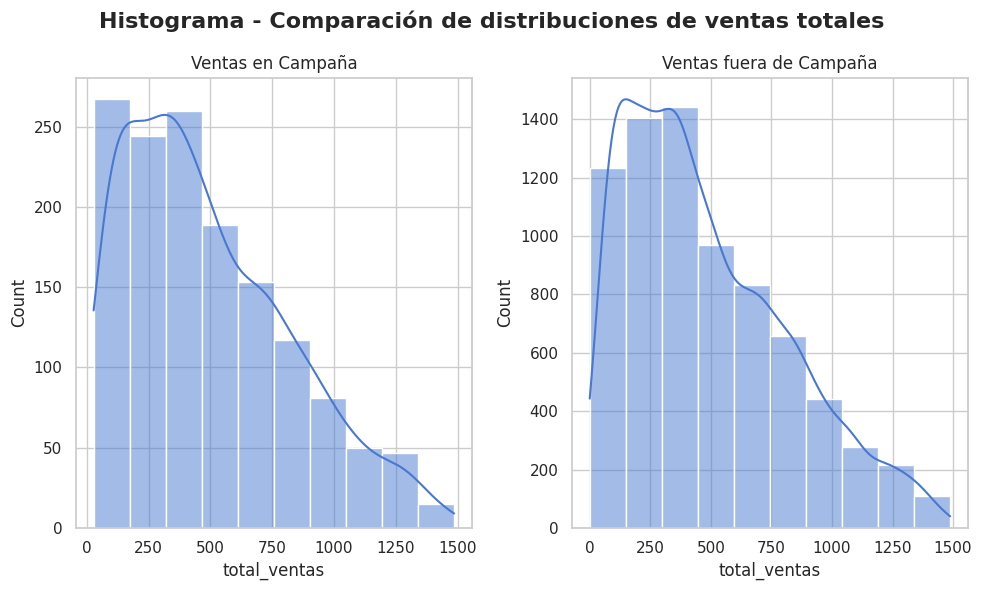

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

# Título general
plt.suptitle(
    "Histograma - Comparación de distribuciones de ventas totales",
    fontsize=16,
    fontweight="bold"
)

# Histograma ventas en campaña
plt.subplot(1, 2, 1) # 1 fila, 2 columnas - primer bloque
sns.histplot(df_impacto["total_ventas"], kde=True, bins=10)
plt.title("Ventas en Campaña")

# Histograma ventas fuera de campaña
plt.subplot(1, 2, 2) # 1 fila, 2 columnas - segundo bloque
sns.histplot(df_inactivo["total_ventas"], kde=True, bins=10)
plt.title("Ventas fuera de Campaña")

plt.tight_layout()
plt.show()

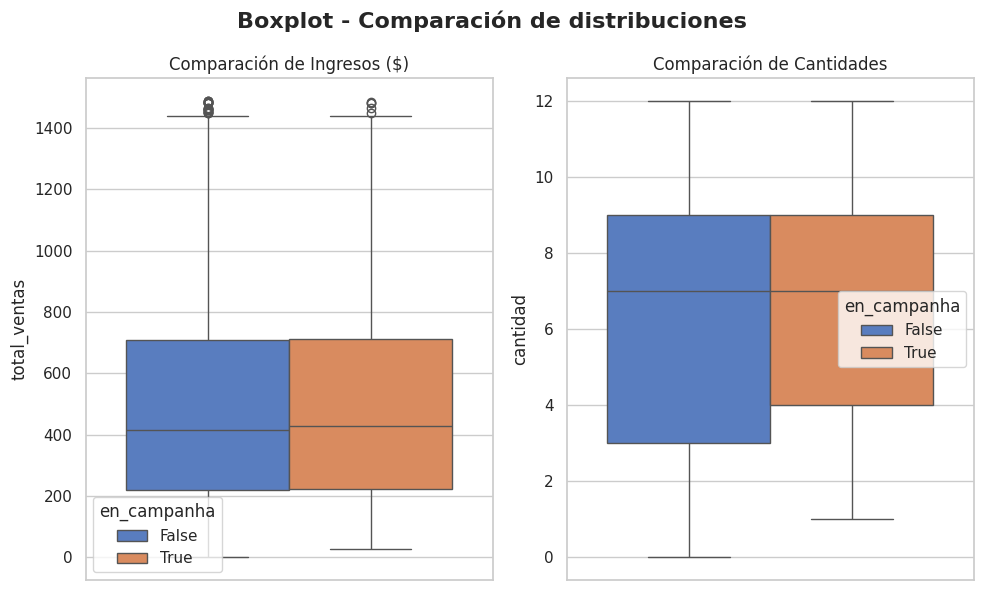

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

# Título general
plt.suptitle(
    "Boxplot - Comparación de distribuciones",
    fontsize=16,
    fontweight="bold"
)

# Boxplot comparación de ventas (Monto en $)
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df_integrado,
    y="total_ventas",
    hue="en_campanha"
)
plt.title("Comparación de Ingresos ($)")

# Boxplot comparación de cantidades vendidas (Unidades)
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_integrado,
    y="cantidad",
    hue="en_campanha"
)
plt.title("Comparación de Cantidades")

plt.tight_layout()
plt.show()

---
### **Correlación 🔆​**

Se muestra la relación entre distintas variables en un mapa de calor


In [ ]:
corr_en_campana = df_impacto[["precio", "cantidad", "total_ventas", "costo"]].corr()
corr_en_campana

,precio,cantidad,total_ventas,costo
precio,1.000000,0.012634,0.560408,0.025725
cantidad,0.012634,1.000000,0.781774,0.016198
total_ventas,0.560408,0.781774,1.000000,0.028930
costo,0.025725,0.016198,0.028930,1.000000


<Axes: >

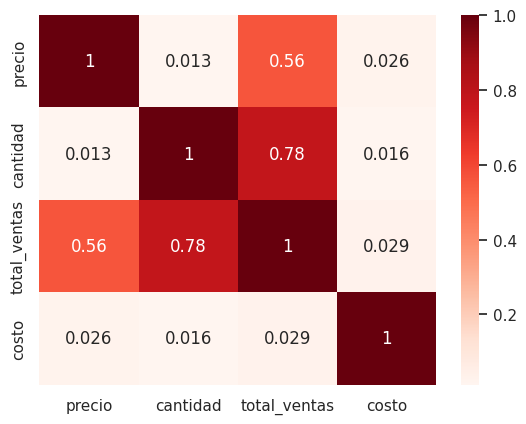

In [ ]:
sns.heatmap(corr_en_campana, annot=True, cmap="Reds")

---

### **Consolidación de Datos 🔆​**



In [ ]:
df_integrado["month"] = df_integrado["fecha_venta"].dt.month

df_tiempo = df_integrado.groupby(["month", "en_campanha"], as_index=False).agg(
    venta_promedio = ("total_ventas", "mean"),
    costo_total = ("costo", "sum")
)

df_tiempo["estado"] = df_tiempo["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

df_tiempo.drop(columns=["en_campanha"], inplace=True)
df_tiempo.sort_values(by="month", ascending=True, inplace=True)

df_tiempo.head()

,month,venta_promedio,costo_total,estado
0,1,479.619428,3910.10,Fuera de campaña
1,1,493.673043,110.97,En campaña
2,2,481.808698,3552.25,Fuera de campaña
3,2,427.400889,212.46,En campaña
4,3,513.989033,3501.05,Fuera de campaña


In [ ]:
df_prod_estado = df_integrado.groupby(["producto", "en_campanha"], as_index=False).agg(
    venta_promedio = ("total_ventas", "mean")
)

df_prod_estado["estado"] = df_prod_estado["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

df_prod_estado.drop(columns=["en_campanha"], inplace=True)
df_prod_estado.sort_values(by="venta_promedio", ascending=False, inplace=True)

df_prod_estado.head()

,producto,venta_promedio,estado
29,Heladera,668.595000,En campaña
43,Parlantes Bluetooth,564.635217,En campaña
18,Cuadro decorativo,560.853029,Fuera de campaña
41,Microondas,559.018814,En campaña
59,Televisor,548.029524,En campaña


In [ ]:
df_activa_prod = df_impacto.groupby(["producto"], as_index=False).agg(
    venta_promedio = ("total_ventas", "mean"),
    costo_total = ("costo", "sum")
)
df_activa_prod.sort_values(by="venta_promedio", ascending=False, inplace=True)

df_activa_prod_long = pd.melt(
    df_activa_prod,
    id_vars=["producto"],
    value_vars=["venta_promedio", "costo_total"],
    var_name="metrica",
    value_name="valor"
)

df_activa_prod_long.head()

,producto,metrica,valor
0,Heladera,venta_promedio,668.595000
1,Parlantes Bluetooth,venta_promedio,564.635217
2,Microondas,venta_promedio,559.018814
3,Televisor,venta_promedio,548.029524
4,Secadora,venta_promedio,544.186104


# **📎​Etapa 4: Visualización de Datos**

---

### **Visualización con Seaborn​**



/tmp/ipykernel_1061/3109961839.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_integrado, x="canal", y="total_ventas", palette="Set2", legend=False)


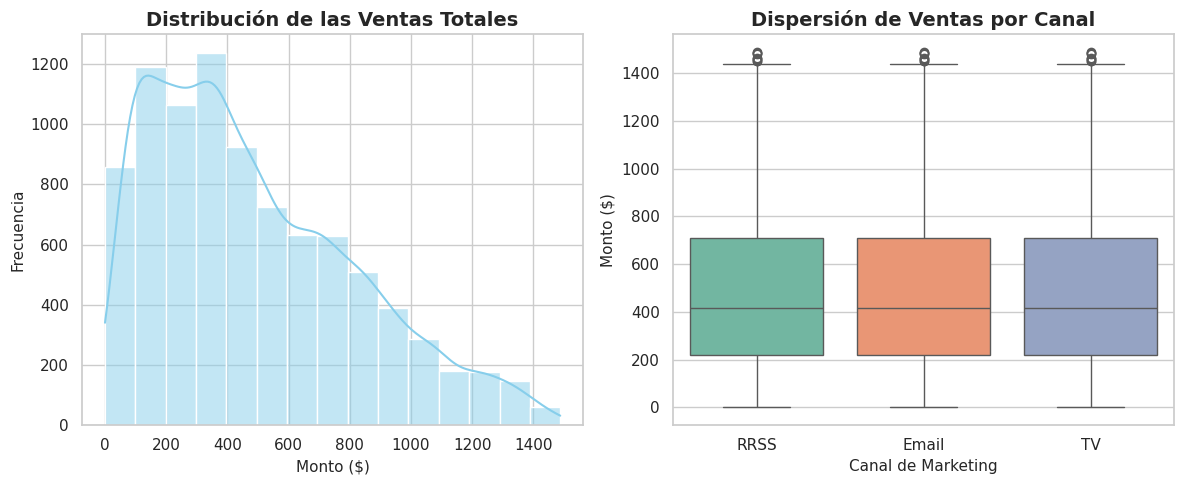

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid", palette="pastel")

# Histograma de la variable de interés principal => Ventas Totales
plt.subplot(1, 2, 1)
sns.histplot(df_integrado["total_ventas"], kde=True, color="skyblue", bins=15)
plt.title("Distribución de las Ventas Totales", fontsize=14, weight="bold")
plt.xlabel("Monto ($)", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)

# Boxplot cruzando Ventas y Canal de Marketing
plt.subplot(1, 2, 2)
sns.boxplot(data=df_integrado, x="canal", y="total_ventas", palette="Set2", legend=False)
plt.title("Dispersión de Ventas por Canal", fontsize=14, weight="bold")
plt.xlabel("Canal de Marketing", fontsize=11)
plt.ylabel("Monto ($)", fontsize=11)

plt.tight_layout()
plt.show()

---

### **Visualización Interactiva con Plotly**



In [ ]:
import plotly.express as px

# Evolución temporal
fig_line = px.line(
    df_tiempo,
    x="month",
    y="venta_promedio",
    color="estado",
    markers=True,
    title="Evolución Mensual de la Venta Promedio",
    labels={
        "month": "Mes",
        "venta_promedio": "Venta Promedio ($)",
        "estado": "Estado"
    }
)
fig_line.update_layout(template="plotly_white", xaxis=dict(dtick=1))
fig_line.show()

# Comparación por Producto
fig_bar = px.bar(
    df_prod_estado,
    x="producto",
    y="venta_promedio",
    color="estado",
    barmode="group",
    title="Venta Promedio por Producto: RRSS Activas vs Inactivas",
    labels={
        "producto": "Producto",
        "venta_promedio": "Venta Promedio ($)",
        "estado": "Estado"
    },
    color_discrete_map={
        "En campaña": "#4C78A8",
        "Fuera de campaña": "#F58518"
    }
)
fig_bar.update_layout(template="plotly_white", xaxis_tickangle=-45)
fig_bar.show()

# Extra: Exportamos los gráficos a formato HTML para que los puedas usar en tu web
html_lineplot = fig_line.to_html(full_html=False, include_plotlyjs="cdn")
html_barplot = fig_bar.to_html(full_html=False, include_plotlyjs="cdn")